<a href="https://colab.research.google.com/github/pavithrasmv/Mchine-learning/blob/main/ROC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy at threshold 0.90 = 1.0
AUC Score = 1.0


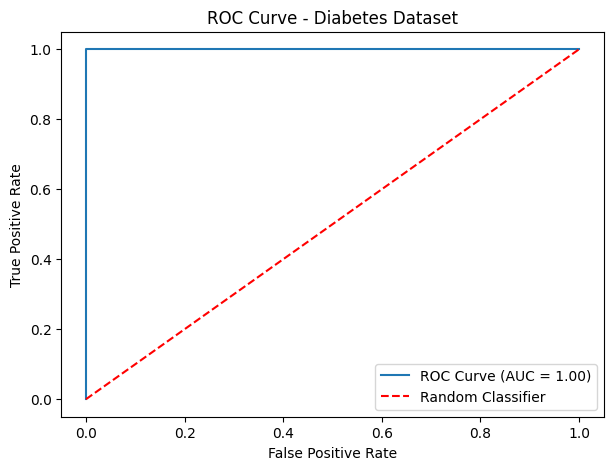

In [7]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


data=pd.read_csv("/content/diabetes_roc.csv")
X = data.drop("Outcome", axis=1)
y = data["Outcome"]
y = (y > y.mean()).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

y_pred_90 = (y_prob >= 0.90).astype(int)
accuracy_90 = accuracy_score(y_test, y_pred_90)
print("Accuracy at threshold 0.90 =", accuracy_90)

fpr, tpr, threshold = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print("AUC Score =", auc)
plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label="ROC Curve (AUC = %.2f)" % auc
)

plt.plot(
    [0, 1],
    [0, 1],
    'r--',
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Diabetes Dataset")
plt.legend()

plt.show()

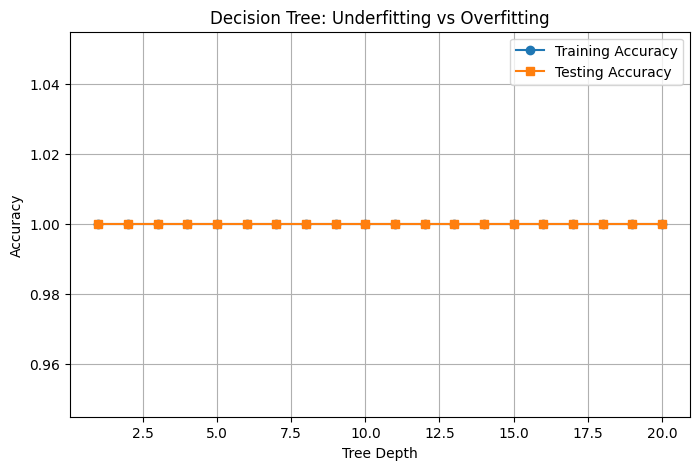

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data=pd.read_csv("/content/custo_churn.csv")
X = data.drop("Churn", axis=1)
y = data["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)
train_accuracy = []
test_accuracy = []

depths = range(1, 21)

for d in depths:
    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(
        y_train,
        train_pred
    )
    test_acc = accuracy_score(
        y_test,
        test_pred
    )
    train_accuracy.append(train_acc)
    test_accuracy.append(test_acc)


# Plot results
plt.figure(figsize=(8, 5))

plt.plot(
    depths,
    train_accuracy,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    depths,
    test_accuracy,
    marker='s',
    label='Testing Accuracy')

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Underfitting vs Overfitting")

plt.legend()
plt.grid()

plt.show()